## Get the data

In [ ]:
import os
import pandas as pd
import numpy as np
data_dir = '/cosma8/data/do012/dc-he4/analysis'

h0_vari = np.array([])
n_sigma = np.array([])
relations = []
for relation, relation_name in zip(['LX-T', 'YSZ-T', 'M-T'], 
                                   ['$L_\\mathrm{{X}}-T$',
                                    '$Y_\\mathrm{{SZ}}-T$',
                                    '$M_\\mathrm{{gas}}-T$']):
    delta_list = []
    delta_err_low_list = []
    for lc in range(1728):
        lc00 = f'{lc:04d}'

        filename = f'{data_dir}/lc{lc00}/h0_mcmc_random.csv'

        if os.path.exists(filename):

            df = pd.read_csv(filename)
            
            cnt = 0
            for rl in ['LX-T', 'YSZ-T', 'M-T']:  # Make sure all three relations are in
                if rl in df['scaling_relation'].values:
                    cnt += 1

            if cnt == 3:
                delta = df[df['scaling_relation']==relation]['delta'].values[0]
                delta_err_low = df[df['scaling_relation']==relation]['delta_err_lower'].values[0]
                delta_list.append(delta)
                delta_err_low_list.append(delta_err_low)
            else:
                continue
        else:
            continue

    h0_variation = 2 * np.array(delta_list)
    significance = np.array(delta_list) / np.array(delta_err_low_list)
    print(len(significance))

    h0_vari = np.concatenate((h0_vari, h0_variation))
    n_sigma = np.concatenate((n_sigma, significance))
    relations += [relation_name for i in range(len(significance))] 

1017
1017
1017


### Save

In [4]:
data = pd.DataFrame({
    '$\\Delta H_0\\,(\\%)$': h0_vari * 100,
    'Significance $(\\sigma)$': n_sigma,
    'Relations': relations
})
data.to_csv('/cosma/home/do012/dc-he4/anisotropy-flamingo/data/analysis_all/h0_mcmc_random.csv')

## Load the data again

In [5]:
# Read the data
import pandas as pd
data = pd.read_csv('/cosma/home/do012/dc-he4/anisotropy-flamingo/data/analysis_all/h0_mcmc_random.csv')

### Plot

/cosma/home/do012/dc-he4/.conda/envs/halo-cosma/lib/python3.8/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


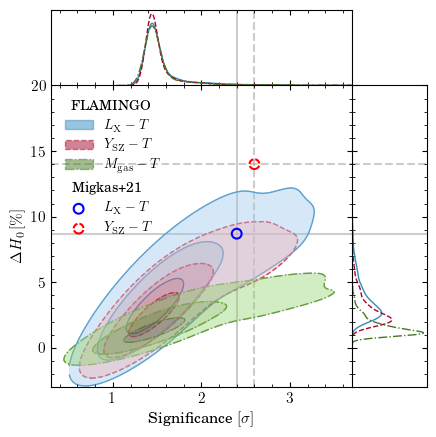

In [6]:
# ---------------------------------------------------------------------------- #
#                                Plot for print                                #
# ---------------------------------------------------------------------------- #
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
plt.style.use('./nice.mplstyle')

# set y lim manually. The ylim argument in jointgrid stretch the histogram
data = data[data['$\\Delta H_0\\,(\\%)$'] < 25]  

# Set colors and linestyles
colors = ['#348ABD', '#A60628', '#467821']
linestyles = ['solid', '--', '-.']  # solid, densely dashed, densely dashdotdotted https://matplotlib.org/stable/gallery/lines_bars_and_markers/linestyles.html
legend_fontsize = 10
contour_linewidth = 1

# Create the 2D KDE plot
g = sns.JointGrid(data=data, 
                    x='Significance $(\\sigma)$',
                    y='$\\Delta H_0\\,(\\%)$', 
                    hue='Relations',
                    space=0,
                    ratio=4,
                    height=4.5,
                    xlim=(0.3, 3.7),
                    ylim=(-3, 20),
                    )

# kde plot missing 3rd level contour if use g.plot_joint, for unknown reason
for relation, color, linestyle in zip(['$L_\\mathrm{{X}}-T$', '$Y_\\mathrm{{SZ}}-T$', '$M_\\mathrm{{gas}}-T$'], 
                            colors, linestyles):

    # Line contours
    sns.kdeplot(data=data[data['Relations'] == relation], 
                x='Significance $(\\sigma)$',
                y='$\\Delta H_0\\,(\\%)$', 
                #hue='Relations',
                color=color,
                fill=False, 
                levels=(0.011, 0.14, 0.61, 1.),
                bw_adjust=3.2, # 3.2,
                zorder=1,
                linestyles=linestyle,
                linewidths=contour_linewidth,
                ax=g.ax_joint
                )
    
    # Filled contours
    sns.kdeplot(data=data[data['Relations'] == relation], 
                x='Significance $(\\sigma)$',
                y='$\\Delta H_0\\,(\\%)$', 
                #hue='Relations',
                color=color,
                fill=True, 
                levels=(0.011, 0.14, 0.61, 1.), # 3 sigma is 0.011
                bw_adjust=3.2, # 3.2,
                zorder=2,
                alpha=0.4,
                ax=g.ax_joint,
                )

    # Marginal histograms
    sns.kdeplot(data=data[data['Relations'] == relation], 
                x='Significance $(\\sigma)$',
                fill=False,
                color=color,
                linestyle=linestyle,
                ax=g.ax_marg_x
    )
   
    sns.kdeplot(data=data[data['Relations'] == relation], 
                y='$\\Delta H_0\\,(\\%)$',
                fill=False,
                color=color,
                linestyle=linestyle,
                ax=g.ax_marg_y,
    )

# M21 results: Lx-T
x_point = 2.4
y_point = 8.7
g.refline(x=x_point, y=y_point, linestyle=linestyles[0], color='grey', linewidth=1.5, alpha=0.4, zorder=0)
line0 = g.ax_joint.scatter(x_point, y_point, marker='o', s=50, 
    linewidths=1.5, facecolor='none', edgecolors='b', linestyle=linestyles[0],
    label='$L_\\mathrm{{X}}-T$', zorder=10)
#g.ax_joint.axhspan(ymin=8.7-3.1, ymax=8.7+3.1, color='tab:blue', alpha=0.2, zorder=0)

# M21 results: Ysz-T
x_point = 2.6
y_point = 14
g.refline(x=x_point, y=y_point, linestyle=linestyles[1], color='grey', linewidth=1.5, alpha=0.4, zorder=0)
line1 = g.ax_joint.scatter(x_point, y_point, marker='o', s=50, 
    linewidths=1.5, facecolor='none', edgecolors='r', linestyle=(0, (3, 1)),
    label='$Y_\\mathrm{{SZ}}-T$', zorder=10)
#g.ax_joint.axhspan(ymin=14.0-3.4, ymax=14.0+3.4, color='tab:orange', alpha=0.2, zorder=0)

# Also add the box for the marginal plots
g.ax_marg_x.spines['top'].set_visible(True)
g.ax_marg_x.spines['right'].set_visible(True)
g.ax_marg_x.spines['left'].set_visible(True)
g.ax_marg_x.spines['bottom'].set_visible(True)

g.ax_marg_y.spines['top'].set_visible(True)
g.ax_marg_y.spines['right'].set_visible(True)
g.ax_marg_y.spines['left'].set_visible(True)
g.ax_marg_y.spines['bottom'].set_visible(True)

# # matplotlib doesn't detect the contour correctly, adding it manually
# import matplotlib.patches as mpatches
# contour = mpatches.Patch(color='tab:blue', label='$Y_\\mathrm{{SZ}}-T$')
g.ax_marg_x.legend(handles=[line0, line1], title='Migkas+21', loc='upper left', bbox_to_anchor=(0, -1.1), fontsize=legend_fontsize, title_fontsize=legend_fontsize)

#sns.move_legend(g.ax_joint, loc='upper right', bbox_to_anchor=(1.7, 0.75), title='FLAMINGO')
from matplotlib.patches import Patch
# Create custom legend for contours
contour_legend_elements = [Patch(facecolor=colors[0], edgecolor=colors[0], linestyle=linestyles[0], linewidth=contour_linewidth, label='$L_\\mathrm{X}-T$', alpha=0.5),
                           Patch(facecolor=colors[1], edgecolor=colors[1], linestyle=linestyles[1], linewidth=contour_linewidth, label='$Y_\\mathrm{SZ}-T$', alpha=0.5),
                           Patch(facecolor=colors[2], edgecolor=colors[2], linestyle=linestyles[2], linewidth=contour_linewidth, label='$M_\\mathrm{gas}-T$', alpha=0.5)]

# Add the custom legend for contours
g.ax_joint.legend(handles=contour_legend_elements, title='FLAMINGO', loc='upper left', fontsize=legend_fontsize, title_fontsize=legend_fontsize)
g.set_axis_labels('Significance $[\\sigma]$', '$\\Delta H_0\\,[\\%]$')

# plt.savefig('./to_paper/h0mc_hist_LTYTMT_random.pdf', bbox_inches='tight')
# Show the plot
plt.show()

## Integrate inside the isodensity curves 

In [ ]:
# Read data
import pandas as pd
data = pd.read_csv('/cosma/home/do012/dc-he4/anisotropy-flamingo/data/analysis_all/h0_mcmc_random.csv')
data

,Unnamed: 0,"$\Delta H_0\,(\%)$",Significance $(\sigma)$,Relations
0,0,10.295630,1.922735,$L_\mathrm{{X}}-T$
1,1,4.899787,1.522564,$L_\mathrm{{X}}-T$
2,2,5.149678,1.492285,$L_\mathrm{{X}}-T$
3,3,4.808609,1.526515,$L_\mathrm{{X}}-T$
4,4,7.142180,1.535062,$L_\mathrm{{X}}-T$
...,...,...,...,...
5179,5179,1.017320,1.437845,$M_\mathrm{{gas}}-T$
5180,5180,1.173855,1.431109,$M_\mathrm{{gas}}-T$
5181,5181,1.281169,1.415019,$M_\mathrm{{gas}}-T$
5182,5182,2.818736,1.661044,$M_\mathrm{{gas}}-T$


First an intuitive understanding of the distribution of the points

In [ ]:
dataset = data[data['Relations']=='$L_\\mathrm{{X}}-T$'][['$\Delta H_0\,(\%)$', 'Significance $(\\sigma)$']]
column_name = ['$\Delta H_0\,(\%)$', 'Significance $(\\sigma)$']

print(len(dataset))
print(np.sum(dataset[column_name[0]] > 8.7))
print(np.sum(dataset[column_name[1]] > 2.4))
print(np.sum((dataset[column_name[0]] > 8.7) & (dataset[column_name[1]] > 2.4)))

1724
96
42
33


## Integrate the KDEs

In [ ]:
# Ysz-T
dataset = data[data['Relations']=='$Y_\\mathrm{{SZ}}-T$'][['$\Delta H_0\,(\%)$', 'Significance $(\\sigma)$']]

import numpy as np
import scipy.stats as stats
# gaussian KDE at the point of interest
print(dataset.T.values.shape)
kde = stats.gaussian_kde(dataset.T.values)

x_grid = np.linspace(-20, 40, 500) # delta H0
y_grid = np.linspace(-10, 20, 500)  # significance
X, Y = np.meshgrid(x_grid, y_grid)
positions = np.vstack([X.ravel(), Y.ravel()])
Z = kde(positions).reshape(X.shape)
print(Z.shape)
# print(Z)

# find probability mass above the point of interest
point = np.array([14, 2.6])
prob = kde(point)*(x_grid[1]-x_grid[0])*(y_grid[1]-y_grid[0])
prob_mass = Z*(x_grid[1]-x_grid[0])*(y_grid[1]-y_grid[0]) # probability mass in each bin
prob_above = np.sum(prob_mass[prob_mass > prob])
prob_below = np.sum(prob_mass[prob_mass < prob])
print(np.sum(prob_mass))
print(prob_above, prob_below)
print('p-value =',1 - prob_above)

(2, 1728)
(500, 500)
1.0000000000001623
1.0000000000001623 1.850079489701466e-43
-1.6231460620019789e-13


In [5]:
# Lx-T
dataset = data[data['Relations']=='$L_\\mathrm{{X}}-T$'][['$\Delta H_0\,(\%)$', 'Significance $(\\sigma)$']]

import scipy.stats as stats
# gaussian KDE at the point of interest
print(dataset.T.values.shape)
kde = stats.gaussian_kde(dataset.T.values)

x_grid = np.linspace(-15, 40, 500) # delta H0
y_grid = np.linspace(-10, 20, 500)  # significance
X, Y = np.meshgrid(x_grid, y_grid)
positions = np.vstack([X.ravel(), Y.ravel()])
Z = kde(positions).reshape(X.shape)
print(Z.shape)
# print(Z)

# find probability mass above the point of interest
point = np.array([8.7, 2.4])
prob = kde(point)*(x_grid[1]-x_grid[0])*(y_grid[1]-y_grid[0])
prob_mass = Z*(x_grid[1]-x_grid[0])*(y_grid[1]-y_grid[0]) # probability mass in each bin
prob_above = np.sum(prob_mass[prob_mass > prob])
prob_below = np.sum(prob_mass[prob_mass < prob])
print(np.sum(prob_mass))
print(prob_above, prob_below)
print('p-value =', 1 - prob_above)

(2, 1728)
(500, 500)
1.0000000000000075
0.9450936624386092 0.0549063375613984
p-value = 0.05490633756139085


In [ ]:
# solve for 1 sigma
n_sigma = 1
p = np.exp(-n_sigma**2*0.5)
print(p)

0.6065306597126334


In [ ]:
# given p, find the n_sigma
p = np.array([0.05917819788745993, 2.1366893399044073e-07])
n_sigma = np.sqrt(-2*np.log(p))
print(n_sigma)

[2.37789911 5.54235294]


In [29]:
np.sqrt(-2*np.log(0.0036))

3.35464496885142